In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

In [2]:
gdown.download("https://drive.google.com/uc?id=1rqn_eoGU0aN8QC-xK_s4xZ99pgwV1koF", "udemy.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1rqn_eoGU0aN8QC-xK_s4xZ99pgwV1koF
To: /run/media/miko/Autumn/My Projects/Udemy Course Project/udemy.csv
100%|██████████| 3.09M/3.09M [00:00<00:00, 15.9MB/s]


'udemy.csv'

In [3]:
df = pd.read_csv("udemy.csv")
df.head()

,id,title,url,is_paid,num_subscribers,avg_rating,avg_rating_recent,rating,num_reviews,is_wishlisted,num_published_lectures,num_published_practice_tests,created,published_time,discount_price__amount,discount_price__currency,discount_price__price_string,price_detail__amount,price_detail__currency,price_detail__price_string
0,762616,The Complete SQL Bootcamp 2020: Go from Zero t...,/course/the-complete-sql-bootcamp/,True,295509,4.66019,4.67874,4.67874,78006,False,84,0,2016-02-14T22:57:48Z,2016-04-06T05:16:11Z,455.0,INR,₹455,8640.0,INR,"₹8,640"
1,937678,Tableau 2020 A-Z: Hands-On Tableau Training fo...,/course/tableau10/,True,209070,4.58956,4.60015,4.60015,54581,False,78,0,2016-08-22T12:10:18Z,2016-08-23T16:59:49Z,455.0,INR,₹455,8640.0,INR,"₹8,640"
2,1361790,PMP Exam Prep Seminar - PMBOK Guide 6,/course/pmp-pmbok6-35-pdus/,True,155282,4.59491,4.59326,4.59326,52653,False,292,2,2017-09-26T16:32:48Z,2017-11-14T23:58:14Z,455.0,INR,₹455,8640.0,INR,"₹8,640"
3,648826,The Complete Financial Analyst Course 2020,/course/the-complete-financial-analyst-course/,True,245860,4.54407,4.53772,4.53772,46447,False,338,0,2015-10-23T13:34:35Z,2016-01-21T01:38:48Z,455.0,INR,₹455,8640.0,INR,"₹8,640"
4,637930,An Entire MBA in 1 Course:Award Winning Busine...,/course/an-entire-mba-in-1-courseaward-winning...,True,374836,4.47080,4.47173,4.47173,41630,False,83,0,2015-10-12T06:39:46Z,2016-01-11T21:39:33Z,455.0,INR,₹455,8640.0,INR,"₹8,640"


In [4]:
df.shape

(13608, 20)

13,608 courses to work with. Let me check what columns we have and if there's any missing data.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13608 entries, 0 to 13607
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            13608 non-null  int64  
 1   title                         13608 non-null  object 
 2   url                           13608 non-null  object 
 3   is_paid                       13608 non-null  bool   
 4   num_subscribers               13608 non-null  int64  
 5   avg_rating                    13608 non-null  float64
 6   avg_rating_recent             13608 non-null  float64
 7   rating                        13608 non-null  float64
 8   num_reviews                   13608 non-null  int64  
 9   is_wishlisted                 13608 non-null  bool   
 10  num_published_lectures        13608 non-null  int64  
 11  num_published_practice_tests  13608 non-null  int64  
 12  created                       13608 non-null  object 
 13  p

Some nulls in `discount_price__amount` and `price_detail__amount`. Are those the free courses?

In [6]:
df[df['discount_price__amount'].isna()]['is_paid'].value_counts()

is_paid
True     907
False    496
Name: count, dtype: int64

All 1,403 missing discount prices come from free courses — makes sense, there's no price to discount. No need to impute these with some value, that would actually be wrong.

Also noticed `is_wishlisted` is always False — useless column. And I don't need `url` or the duplicate rating/currency string columns.

In [7]:
# drop columns that won't help
df.drop(columns=['avg_rating', 'avg_rating_recent', 'url',
                 'discount_price__currency', 'price_detail__currency',
                 'discount_price__price_string', 'price_detail__price_string',
                 'is_wishlisted'], inplace=True)

# fix date columns
df['created'] = pd.to_datetime(df['created'])
df['published_time'] = pd.to_datetime(df['published_time'])

# split paid and free
paid = df[df['is_paid'] == True].copy()
free = df[df['is_paid'] == False].copy()

print(f"Paid: {len(paid)}, Free: {len(free)}")

Paid: 13112, Free: 496


In [8]:
# discount percentage for paid courses
paid['discount_pct'] = ((paid['price_detail__amount'] - paid['discount_price__amount'])
                        / paid['price_detail__amount']) * 100

paid[['price_detail__amount', 'discount_price__amount', 'discount_pct']].describe()

,price_detail__amount,discount_price__amount,discount_pct
count,13111.000000,12205.000000,12205.000000
mean,4646.992602,493.943794,82.311193
std,3109.101019,267.827260,12.350324
min,1280.000000,455.000000,40.625000
25%,1600.000000,455.000000,71.562500
50%,3200.000000,455.000000,85.781250
75%,8640.000000,455.000000,94.652778
max,12800.000000,3200.000000,94.741379


Median price is around ₹3,200 but the median discount price is just ₹455 — that's a ~86% discount. Udemy's discounting is aggressive.

What does the rating distribution look like?

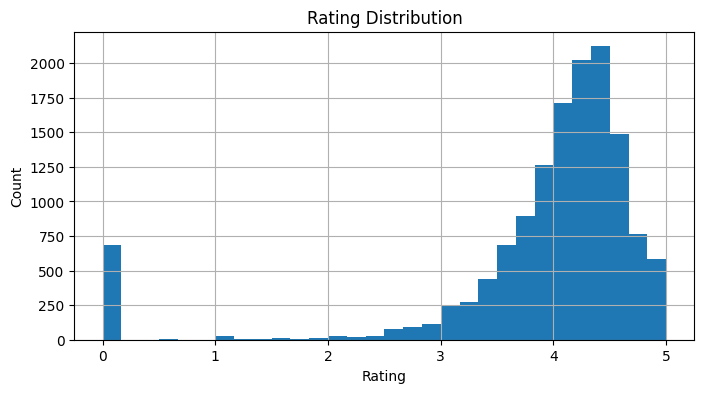

In [9]:
plt.figure(figsize=(8, 4))
df['rating'].hist(bins=30)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Rating Distribution')
plt.show()

There's a big spike at 0. Those are probably courses with no ratings at all — not actually zero-rated. Let me verify.

In [10]:
print(f"Courses with 0 rating: {len(df[df['rating'] == 0])}")
print(f"\nTheir review counts:")
df[df['rating'] == 0]['num_reviews'].describe()

Courses with 0 rating: 684

Their review counts:


count    684.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: num_reviews, dtype: float64

Confirmed — 0 rating means 0 reviews, they're just unrated. Now let me find the genuinely top-rated courses, but only ones with at least 50 reviews. Otherwise I'll just get random courses with one 5-star review.

In [11]:
popular = df[(df['num_reviews'] >= 50) & (df['rating'] > 0)]
top10 = popular.nlargest(10, 'rating')
top10[['title', 'rating', 'num_reviews', 'num_subscribers']]

,title,rating,num_reviews,num_subscribers
3085,Advanced Upwork Interviews: A Simple Way to Ea...,5.00000,71,508
11985,Blockchain și Bitcoin pe înțelesul tuturor - g...,5.00000,90,271
3622,Tools For Inspecting Your Home Or One You May ...,4.98170,53,367
2660,Predictable Revenue Pipedrive Mastery Course,4.98090,90,978
2425,The Advanced Real Estate Equity Waterfall Mode...,4.97113,105,1097
3185,Cold Call University: Courses 101 to 401 - All...,4.95348,68,166
2685,Innovate or Die,4.95256,89,1536
2092,ClickBank Vendor Success – Create & Sell Your ...,4.95001,136,2136
2863,Master Your Abundance Mindset & Prosper Doing ...,4.94707,80,792
3161,Creating a Robust Financial Plan for Your Busi...,4.94385,68,2896


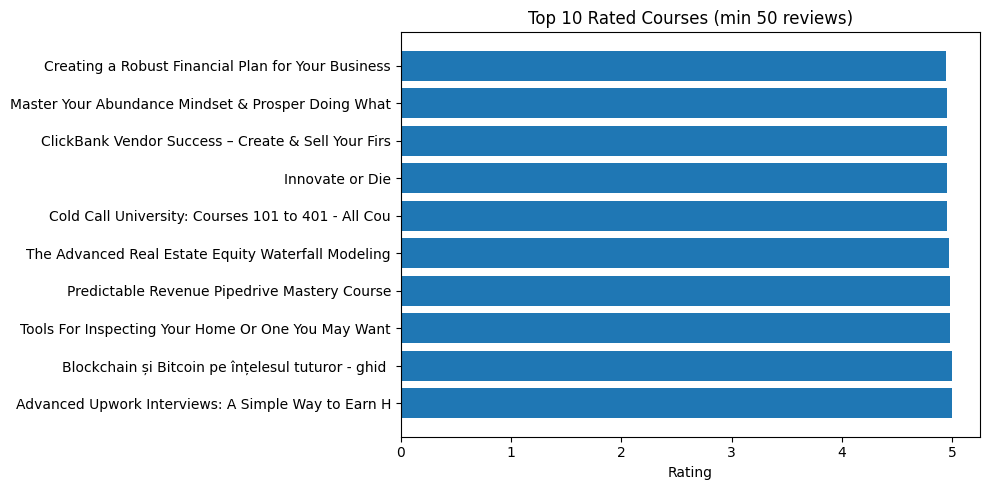

In [12]:
plt.figure(figsize=(10, 5))
plt.barh(top10['title'].str[:50], top10['rating'])
plt.xlabel('Rating')
plt.title('Top 10 Rated Courses (min 50 reviews)')
plt.tight_layout()
plt.show()

These are legit popular courses with thousands of reviews. Now let's check — do highly rated courses actually get more subscribers, or is it unrelated?

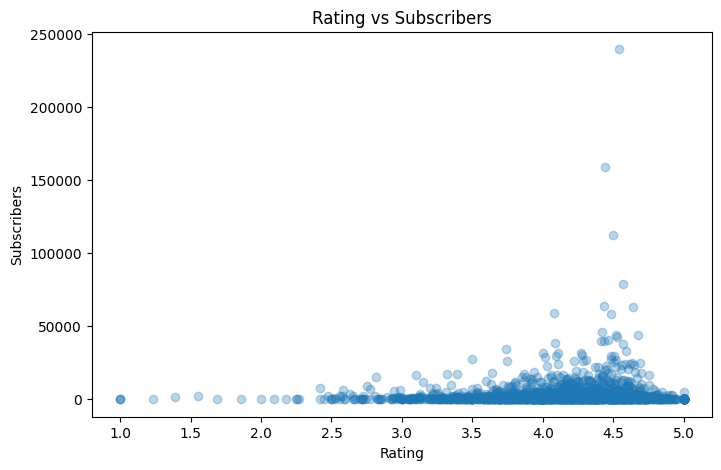


Correlation matrix:


,rating,num_subscribers,num_reviews
rating,1.000000,0.050052,0.077461
num_subscribers,0.050052,1.000000,0.784113
num_reviews,0.077461,0.784113,1.000000


In [13]:
rated = df[df['rating'] > 0]

plt.figure(figsize=(8, 5))
sample = rated.sample(min(2000, len(rated)), random_state=42)
plt.scatter(sample['rating'], sample['num_subscribers'], alpha=0.3)
plt.xlabel('Rating')
plt.ylabel('Subscribers')
plt.title('Rating vs Subscribers')
plt.show()

print("\nCorrelation matrix:")
rated[['rating', 'num_subscribers', 'num_reviews']].corr()

Weak correlation between rating and subscribers. Rating alone doesn't drive enrollment. Reviews and subscribers are more correlated though — makes sense, more students = more reviews.

What about the most subscribed courses?

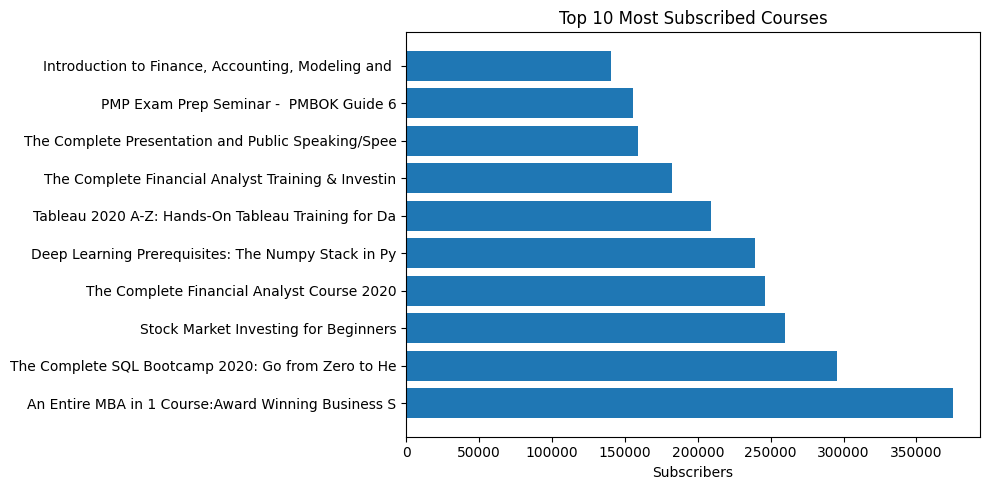

In [14]:
top_subs = df.nlargest(10, 'num_subscribers')

plt.figure(figsize=(10, 5))
plt.barh(top_subs['title'].str[:50], top_subs['num_subscribers'])
plt.xlabel('Subscribers')
plt.title('Top 10 Most Subscribed Courses')
plt.tight_layout()
plt.show()

Do cheaper courses get more subscribers?

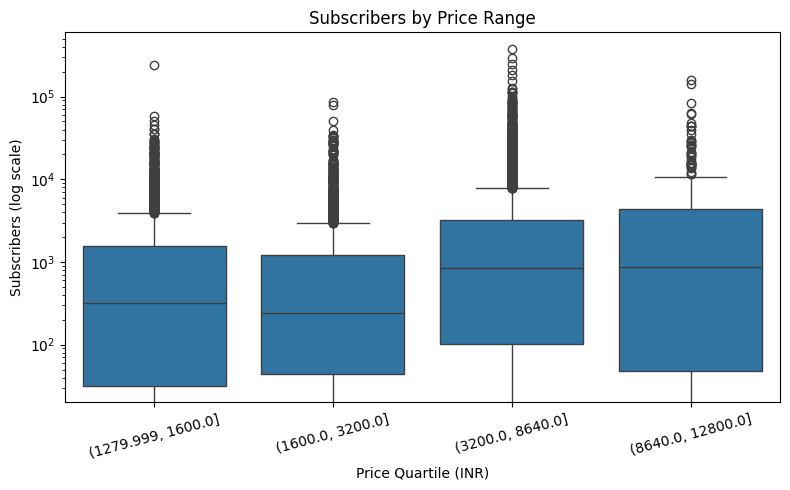

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=paid, x=pd.qcut(paid['price_detail__amount'], 4, duplicates='drop'),
            y='num_subscribers')
plt.yscale('log')
plt.xlabel('Price Quartile (INR)')
plt.ylabel('Subscribers (log scale)')
plt.title('Subscribers by Price Range')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Cheaper courses don't clearly win. The higher-priced quartiles actually have slightly higher median subscribers. Every price range has massive outlier courses at the top though. Pricing alone doesn't seem to determine popularity.

How has course publishing grown over the years?

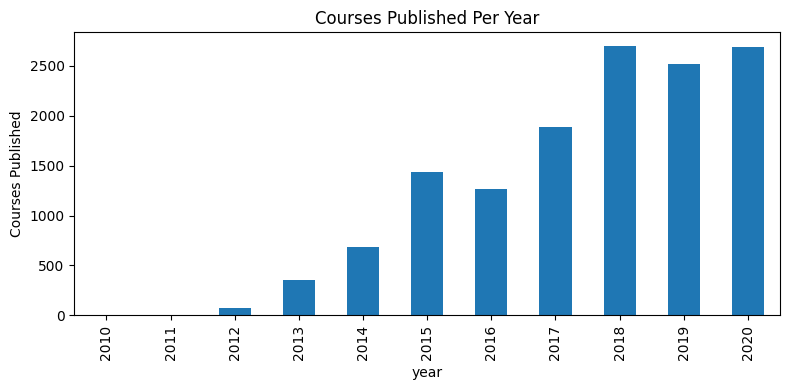

In [16]:
df['year'] = df['published_time'].dt.year
courses_per_year = df['year'].value_counts().sort_index()

courses_per_year.plot(kind='bar', figsize=(8, 4))
plt.ylabel('Courses Published')
plt.title('Courses Published Per Year')
plt.tight_layout()
plt.show()

Big growth from ~2015 to 2020.

Finally — how does the free vs paid split look?

Free: 496 (3.6%)
Paid: 13112 (96.4%)


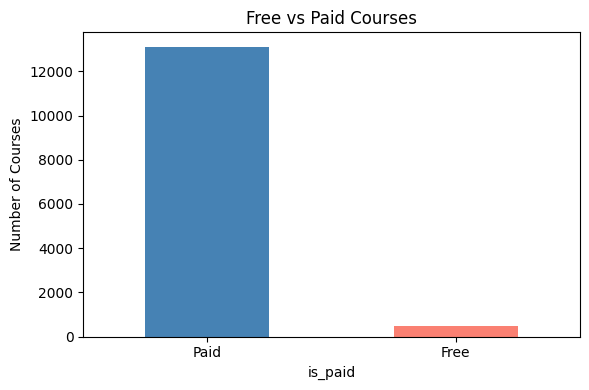

In [17]:
print(f"Free: {len(free)} ({len(free)/len(df)*100:.1f}%)")
print(f"Paid: {len(paid)} ({len(paid)/len(df)*100:.1f}%)")

plt.figure(figsize=(6, 4))
df['is_paid'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.xticks([0, 1], ['Paid', 'Free'], rotation=0)
plt.ylabel('Number of Courses')
plt.title('Free vs Paid Courses')
plt.tight_layout()
plt.show()

Overwhelming majority (~96%) are paid courses. The free ones are a tiny fraction.